Impoting libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


In [3]:
# setting make number easier to read and display
pd.options.display.float_format='{:20.2f}'.format
#show all columns on op
pd.set_option('display.max_columns',999)

Data Exploration

In [4]:
data=pd.read_csv("D:\Customer-Segmentation\online_retail_II.csv.zip")
data.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [5]:
data.describe()


,Quantity,Price,Customer ID
count,1067371.00,1067371.00,824364.00
mean,9.94,4.65,15324.64
std,172.71,123.55,1697.46
min,-80995.00,-53594.36,12346.00
25%,1.00,1.25,13975.00
50%,3.00,2.10,15255.00
75%,10.00,4.15,16797.00
max,80995.00,38970.00,18287.00


In [6]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [7]:
# check object dtypes
data.describe(include='O')


,Invoice,StockCode,Description,InvoiceDate,Country
count,1067371,1067371,1062989,1067371,1067371
unique,53628,5305,5698,47635,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2010-12-06 16:57:00,United Kingdom
freq,1350,5829,5918,1350,981330


In [8]:
# Finding Null values
data[data["Customer ID"].isna()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [9]:
# check if quantity value has negative values
data[data["Quantity"]<0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.00,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.00,United Kingdom


In [10]:
# convert invoice dtype into string and check if invoice has 6 digits
data["Invoice"] = data["Invoice"].astype(str)
data[data["Invoice"].str.match("^\\d{6}$")==False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.00,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.00,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.00,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.00,United Kingdom


In [11]:
# chech invoice has only numbers and unique
data["Invoice"].str.replace("0-9","",regex=True).unique()

array(['489434', '489435', '489436', ..., '581585', '581586', '581587'],
      shape=(53628,), dtype=object)

In [12]:
# check if invoice value start with 'A'
data[data["Invoice"].str.startswith("A")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [13]:
# check if stockcode has 5 values
data["StockCode"]=data["StockCode"].astype(str)
data[(data["StockCode"].str.match("^\\d{5}$")== False)&(data["StockCode"].str.match("^\\d{5}[a-zA-Z]+$")==False)]["StockCode"].unique()

array(['POST', 'D', 'DCGS0058', 'DCGS0068', 'DOT', 'M', 'DCGS0004',
       'DCGS0076', 'C2', 'BANK CHARGES', 'DCGS0003', 'TEST001',
       'gift_0001_80', 'DCGS0072', 'gift_0001_20', 'DCGS0044', 'TEST002',
       'gift_0001_10', 'gift_0001_50', 'DCGS0066N', 'gift_0001_30',
       'PADS', 'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70',
       'gift_0001_90', 'DCGSSGIRL', 'DCGS0006', 'DCGS0016', 'DCGS0027',
       'DCGS0036', 'DCGS0039', 'DCGS0060', 'DCGS0056', 'DCGS0059', 'GIFT',
       'DCGSLBOY', 'm', 'DCGS0053', 'DCGS0062', 'DCGS0037', 'DCGSSBOY',
       'DCGSLGIRL', 'S', 'DCGS0069', 'DCGS0070', 'DCGS0075', 'B',
       'DCGS0041', 'ADJUST2', '47503J ', 'C3', 'SP1002', 'AMAZONFEE',
       'DCGS0055', 'DCGS0074', 'DCGS0057', 'DCGS0073', 'DCGS0071',
       'DCGS0066P', 'DCGS0067', 'CRUK'], dtype=object)

In [14]:
# check all values if it is ligide value or not based on customer id null or not
data[data["StockCode"].str.contains("^DOT")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom
2539,489600,DOT,DOTCOM POSTAGE,1,2009-12-01 14:43:00,55.96,NaN,United Kingdom
2551,489601,DOT,DOTCOM POSTAGE,1,2009-12-01 14:44:00,68.39,NaN,United Kingdom
2571,489602,DOT,DOTCOM POSTAGE,1,2009-12-01 14:45:00,59.35,NaN,United Kingdom
2619,489603,DOT,DOTCOM POSTAGE,1,2009-12-01 14:46:00,42.39,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
1062295,581219,DOT,DOTCOM POSTAGE,1,2011-12-08 09:28:00,1008.96,NaN,United Kingdom
1062715,581238,DOT,DOTCOM POSTAGE,1,2011-12-08 10:53:00,1683.75,NaN,United Kingdom
1064829,581439,DOT,DOTCOM POSTAGE,1,2011-12-08 16:30:00,938.59,NaN,United Kingdom
1066369,581492,DOT,DOTCOM POSTAGE,1,2011-12-09 10:03:00,933.17,NaN,United Kingdom


Data Cleaning
based on each needed columns

In [15]:
# clean Invoice column
data["Invoice"] = data["Invoice"].astype("str")
mask=(
    data["Invoice"].str.match("^\\d{6}$")==True
)
data=data[mask]
data

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.00,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.00,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.00,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.00,France


In [16]:
#clean stockcode
data["StockCode"]=data["StockCode"].astype("str")
mask=(
    (data["StockCode"].str.match("^\\d{5}$")==True)
    |(data["StockCode"].str.match("^\\d{5}[a-zA-Z]+$")==True)
    |(data["StockCode"].str.match("^PADS$")==True)
)
data=data[mask]
data

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.00,France
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.00,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.00,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.00,France


In [17]:
# remove null customer ids
data.dropna(subset=['Customer ID'],inplace=True)

C:\Users\Pasupathi\AppData\Local\Temp\ipykernel_3512\327061380.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(subset=['Customer ID'],inplace=True)


In [18]:
data.describe()

,Quantity,Price,Customer ID
count,802711.00,802711.00,802711.00
mean,13.34,2.93,15338.07
std,144.54,4.28,1693.93
min,1.00,0.00,12346.00
25%,2.00,1.25,13988.00
50%,5.00,1.95,15276.00
75%,12.00,3.75,16809.00
max,80995.00,649.50,18287.00


In [19]:
# check price
len(data[data["Price"]==0.0])

62

In [20]:
data=data[data["Price"]>0]
data.describe()
data["Price"].min()

0.001

Feature Engineering

In [21]:
# in data df adding column TotalAmount
data['TotalAmount']=data['Quantity']*data['Price']

C:\Users\Pasupathi\AppData\Local\Temp\ipykernel_3512\2729556417.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['TotalAmount']=data['Quantity']*data['Price']


In [22]:
# creating monetary and frequency for new df rfm
rfm=data.groupby(by='Customer ID',as_index=False).agg(
    Monetary = ("TotalAmount","sum"),
    Frequency = ("Invoice","nunique"),
    LastInvoiceDate = ("InvoiceDate","max")
)
rfm.head()

,Customer ID,Monetary,Frequency,LastInvoiceDate
0,12346.00,77352.96,3,2011-01-18 10:01:00
1,12347.00,5633.32,8,2011-12-07 15:52:00
2,12348.00,1658.40,5,2011-09-25 13:13:00
3,12349.00,3678.69,3,2011-11-21 09:51:00
4,12350.00,294.40,1,2011-02-02 16:01:00


In [23]:
# creating Recency by (max invoice date - last invoice date)
rfm["LastInvoiceDate"]=pd.to_datetime(rfm["LastInvoiceDate"])
Max_invoice_date = rfm["LastInvoiceDate"].max()
rfm["Recency"]= (Max_invoice_date - rfm["LastInvoiceDate"]).dt.days
rfm.head()

,Customer ID,Monetary,Frequency,LastInvoiceDate,Recency
0,12346.00,77352.96,3,2011-01-18 10:01:00,325
1,12347.00,5633.32,8,2011-12-07 15:52:00,1
2,12348.00,1658.40,5,2011-09-25 13:13:00,74
3,12349.00,3678.69,3,2011-11-21 09:51:00,18
4,12350.00,294.40,1,2011-02-02 16:01:00,309


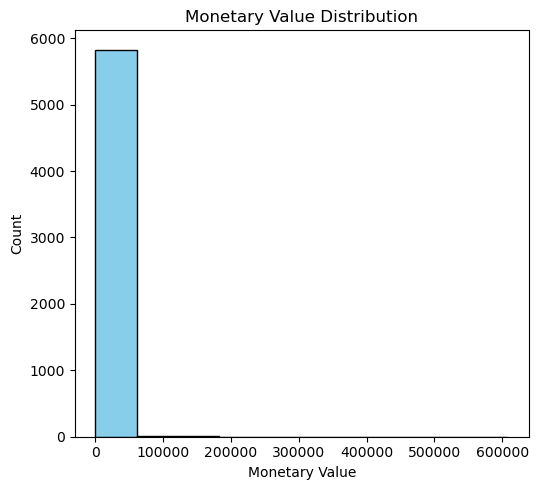

In [24]:
#check the distribution of data and outliers by using hisotgram
plt.figure(figsize=(15,5))
# Monetary Value Distribution
plt.subplot(1,3,1)
plt.hist(rfm["Monetary"],bins=10,color="skyblue",edgecolor="black")
plt.title("Monetary Value Distribution")
plt.xlabel("Monetary Value")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

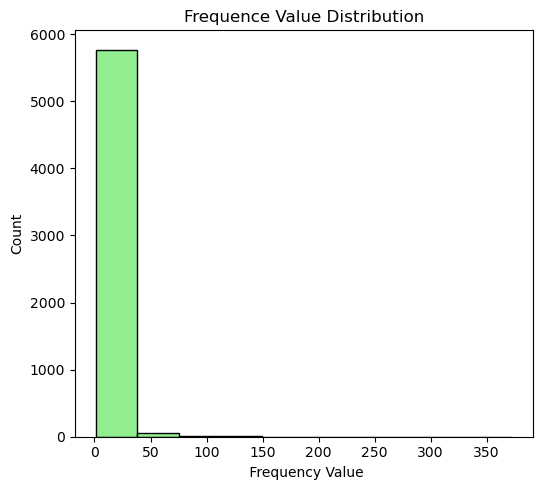

In [25]:
# Frequence Value Distribution
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(rfm["Frequency"],bins=10,color="lightgreen",edgecolor="black")
plt.title("Frequence Value Distribution")
plt.xlabel(" Frequency Value")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


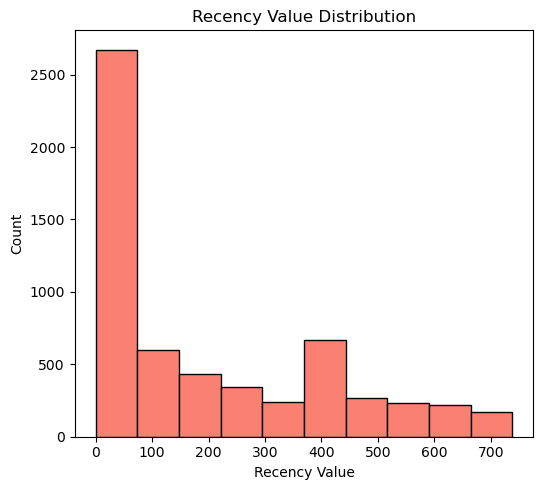

In [26]:
# Recency Value Distribution
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(rfm["Recency"],bins=10,color="salmon",edgecolor="black")
plt.title("Recency Value Distribution")
plt.xlabel("Recency Value")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

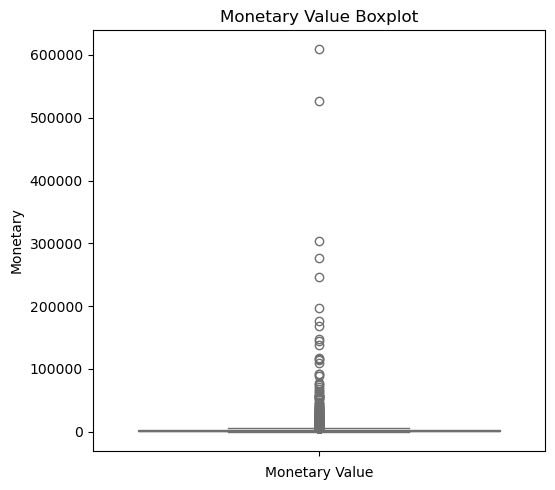

In [27]:
#check the distribution of outliers by using box plot
plt.figure(figsize=(15,5))
# Monetary Value 
plt.subplot(1,3,1)
sns.boxplot(data=rfm["Monetary"],color="skyblue")
plt.title("Monetary Value Boxplot")
plt.xlabel("Monetary Value")

plt.tight_layout()
plt.show()

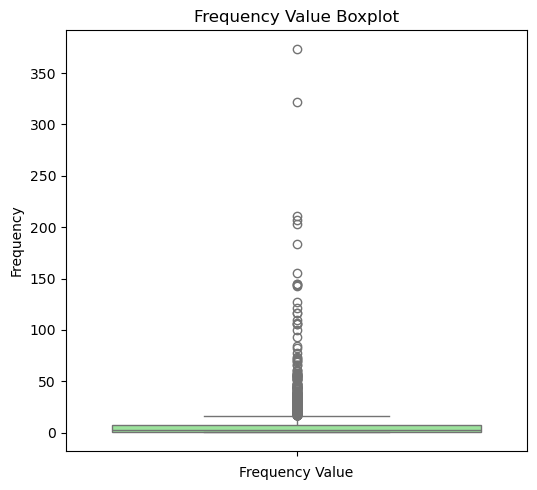

In [28]:
plt.figure(figsize=(15,5))
# Frequency Value 
plt.subplot(1,3,1)
sns.boxplot(data=rfm["Frequency"],color="lightgreen")
plt.title("Frequency Value Boxplot")
plt.xlabel("Frequency Value")

plt.tight_layout()
plt.show()

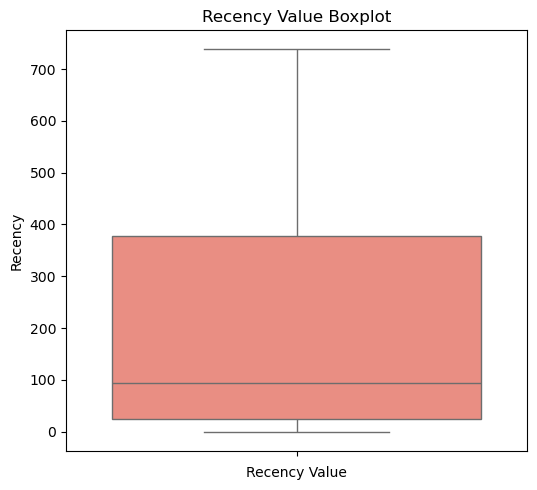

In [29]:
plt.figure(figsize=(15,5))
#  Recency Value 
plt.subplot(1,3,1)
sns.boxplot(data=rfm["Recency"],color="salmon")
plt.title("Recency Value Boxplot")
plt.xlabel("Recency Value")

plt.tight_layout()
plt.show()

In [30]:
# finding quantile for monetary
M_Q1 = rfm["Monetary"].quantile(0.25)
M_Q3 = rfm["Monetary"].quantile(0.75)
M_IQR = M_Q3-M_Q1   #Inter Quantitle Range

In [31]:
#Seperate outliers from monetary
monetary_outliers = rfm[(rfm["Monetary"]>(M_Q3 + 1.5 * M_IQR)) | (rfm["Monetary"]<(M_Q3 - 1.5 * M_IQR))].copy()
monetary_outliers.describe()

,Customer ID,Monetary,Frequency,LastInvoiceDate,Recency
count,620.00,620.00,620.00,620,620.00
mean,15077.78,18260.64,25.98,2011-10-19 01:33:52.548387072,50.98
min,12346.00,5217.44,1.00,2010-01-17 11:33:00,0.00
25%,13573.00,6591.86,12.00,2011-10-23 01:02:00,4.00
50%,14924.00,9131.81,18.00,2011-11-23 12:34:30,16.00
75%,16607.50,14486.35,29.00,2011-12-05 10:27:30,47.25
max,18260.00,608821.65,373.00,2011-12-09 12:49:00,691.00
std,1754.42,41750.24,31.13,NaN,102.87


In [32]:
# finding quantile for frequency
F_Q1 = rfm["Frequency"].quantile(0.25)
F_Q3 = rfm["Frequency"].quantile(0.75)
F_IQR = F_Q3-F_Q1   #Inter Quantitle Range

In [33]:
#Seperate outliers from frequency
frequency_outliers = rfm[(rfm["Frequency"]>(F_Q3 + 1.5 * F_IQR)) | (rfm["Frequency"]<(F_Q3 - 1.5 * F_IQR))].copy()
frequency_outliers.describe()

,Customer ID,Monetary,Frequency,LastInvoiceDate,Recency
count,424.00,424.00,424.00,424,424.00
mean,15373.75,21143.85,34.87,2011-11-08 06:13:43.160377344,30.79
min,12415.00,1820.44,17.00,2010-05-12 16:51:00,0.00
25%,13851.00,6368.09,20.00,2011-11-15 04:14:45,2.75
50%,15306.00,9760.71,25.00,2011-11-30 11:27:30,9.00
75%,16947.25,16691.30,35.00,2011-12-06 12:59:15,24.00
max,18283.00,608821.65,373.00,2011-12-09 12:49:00,575.00
std,1777.62,49369.50,34.68,NaN,70.63


In [34]:
# remove the outliers from the rfm
non_outliers = rfm[(~rfm.index.isin(monetary_outliers))&(~rfm.index.isin(frequency_outliers.index))]
non_outliers.describe()

,Customer ID,Monetary,Frequency,LastInvoiceDate,Recency
count,5428.00,5428.00,5428.00,5428,5428.00
mean,15315.49,1560.33,4.02,2011-05-10 15:45:53.876197376,212.35
min,12346.00,2.95,1.00,2009-12-01 10:49:00,0.00
25%,13836.75,322.90,1.00,2010-11-17 14:45:30,31.00
50%,15321.50,781.43,3.00,2011-08-12 09:24:00,119.00
75%,16791.25,1797.14,6.00,2011-11-08 12:13:15,386.00
max,18287.00,168472.50,16.00,2011-12-09 12:50:00,738.00
std,1710.03,3493.18,3.54,NaN,209.99


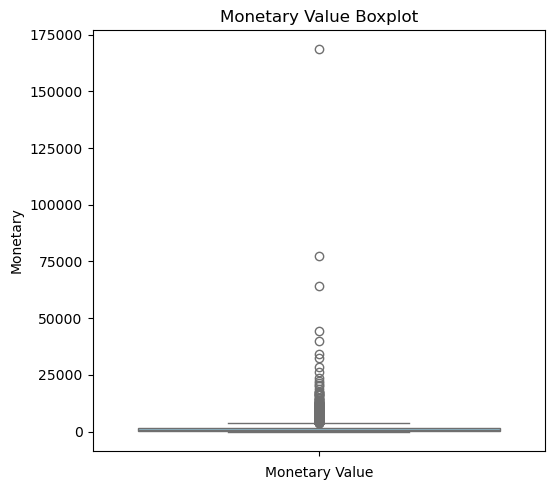

In [35]:
# check once againt it has outliers by box plot
 #check the distribution of outliers by using box plot
plt.figure(figsize=(15,5))
# Monetary Value 
plt.subplot(1,3,1)
sns.boxplot(data=non_outliers["Monetary"],color="skyblue")
plt.title("Monetary Value Boxplot")
plt.xlabel("Monetary Value")

plt.tight_layout()
plt.show()

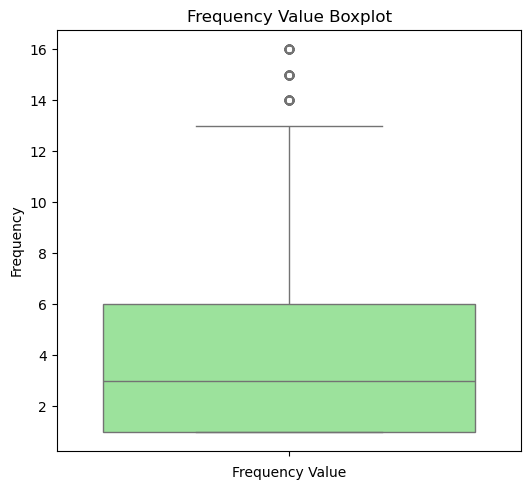

In [36]:
plt.figure(figsize=(15,5))
# Frequency Value 
plt.subplot(1,3,1)
sns.boxplot(data=non_outliers["Frequency"],color="lightgreen")
plt.title("Frequency Value Boxplot")
plt.xlabel("Frequency Value")

plt.tight_layout()
plt.show()

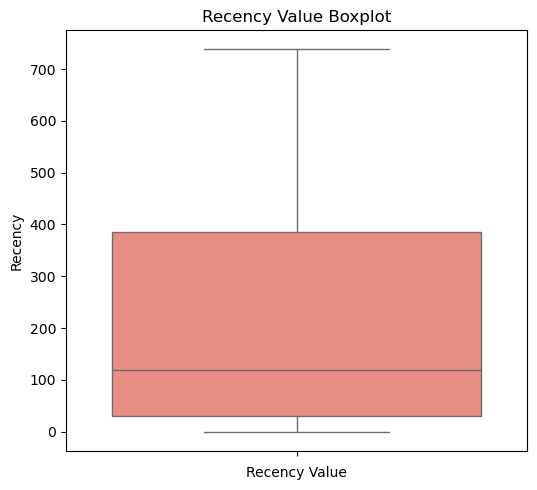

In [37]:
plt.figure(figsize=(15,5))
# Recency Value 
plt.subplot(1,3,1)
sns.boxplot(data=non_outliers["Recency"],color="salmon")
plt.title("Recency Value Boxplot")
plt.xlabel("Recency Value")

plt.tight_layout()
plt.show()

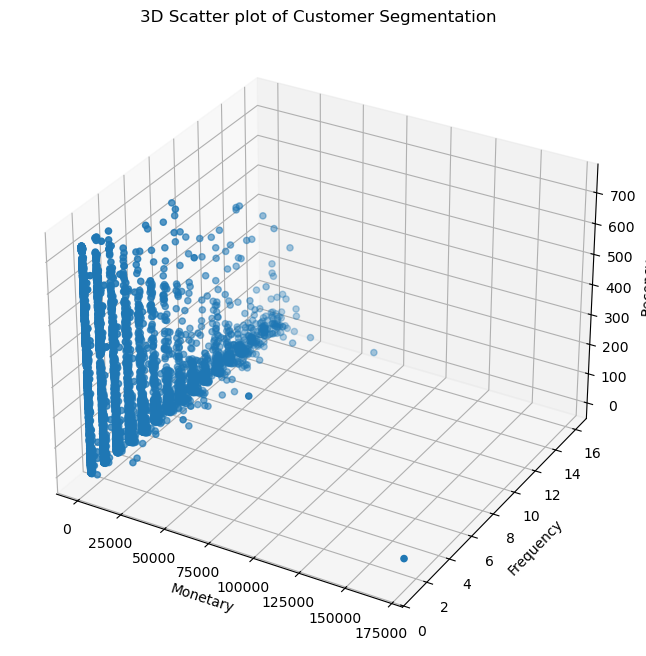

In [38]:
# 3d scatter plot for customer segmentation

fig = plt.figure(figsize=(8,8))
ax=fig.add_subplot(projection="3d")
scatter = ax.scatter(non_outliers["Monetary"],non_outliers["Frequency"],non_outliers["Recency"])
ax.set_xlabel("Monetary")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")
ax.set_title("3D Scatter plot of Customer Segmentation")
plt.show()

Scaling the data

In [39]:
# scaling the data
scalar = StandardScaler()
scalar_data = scalar.fit_transform(non_outliers[["Monetary","Frequency","Recency"]])
scalar_data

array([[21.69933268, -0.28754721,  0.53649213],
       [ 1.16609252,  1.12494715, -1.00659122],
       [ 0.02807807,  0.27745053, -0.6589212 ],
       ...,
       [-0.3387851 , -0.85254495,  2.1319641 ],
       [-0.08986841, -0.57004608,  1.25564516],
       [ 0.73654998,  0.84244827, -0.8113245 ]], shape=(5428, 3))

In [40]:
# convert this resul array into data frame
scalar_data_df = pd.DataFrame(scalar_data,index=non_outliers.index,columns=("Monetary","Frequency","Recency"))
scalar_data_df

,Monetary,Frequency,Recency
0,21.70,-0.29,0.54
1,1.17,1.12,-1.01
2,0.03,0.28,-0.66
3,0.61,-0.29,-0.93
4,-0.36,-0.85,0.46
...,...,...,...
5846,-0.40,-0.57,-0.98
5848,-0.33,-0.85,1.04
5849,-0.34,-0.85,2.13
5850,-0.09,-0.57,1.26


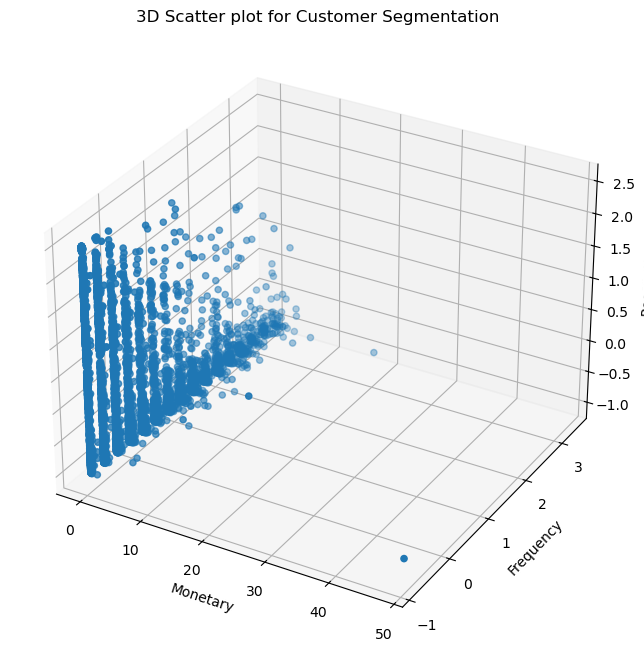

In [41]:
# 3D scatter plot for scalar_data_df
fig=plt.figure(figsize=(8,8))
ax=fig.add_subplot(projection="3d")
scatter = ax.scatter(scalar_data_df["Monetary"],scalar_data_df["Frequency"],scalar_data_df["Recency"])
ax.set_xlabel("Monetary")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")
ax.set_title("3D Scatter plot for Customer Segmentation")
plt.show()

KMeans Clustering

In [42]:
# Elbow method for finding no.of clusters or k values and silhoutte score for more accurate no.of clusters
max_k = 12
inertia = []
silhouette_scores = []
k_values = range(2,max_k+1)
for k in k_values:
    kmeans = KMeans(n_clusters=k,random_state=42,max_iter=1000)
    cluster_labels = kmeans.fit_predict(scalar_data_df)
    sil_score = silhouette_score(scalar_data_df,cluster_labels)
    silhouette_scores.append(sil_score)
    inertia.append(kmeans.inertia_)
    

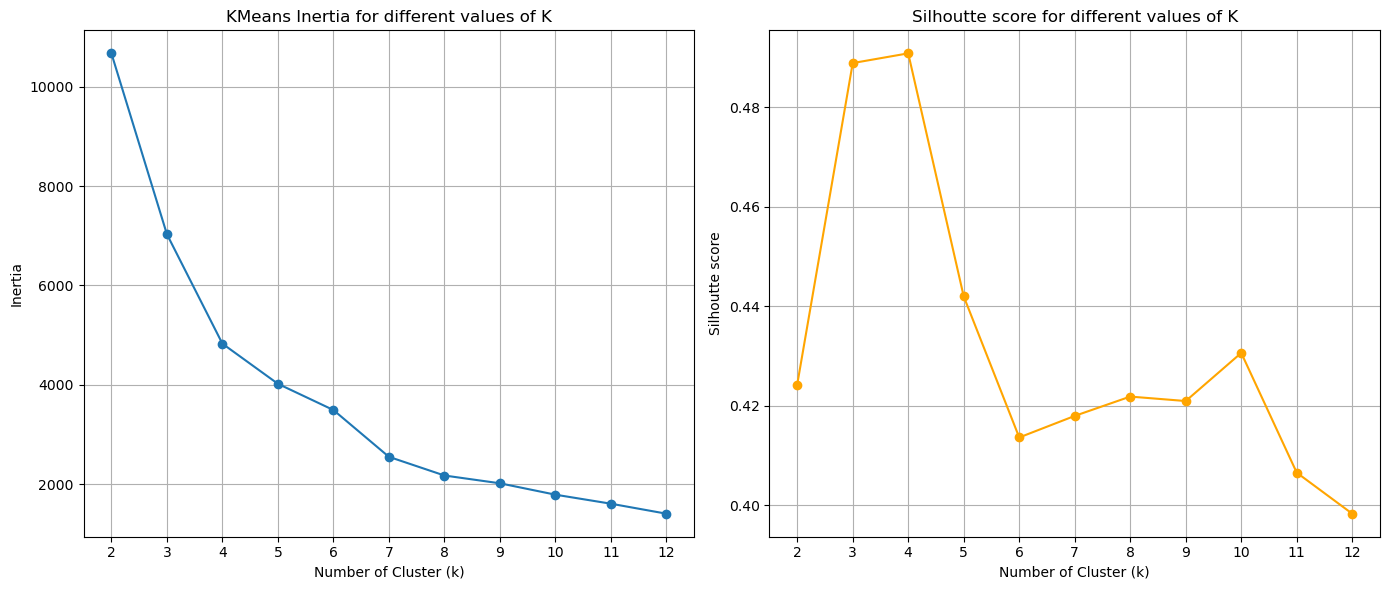

In [43]:
# plots for both elbow method and silhoutte score
plt.figure(figsize=(14,6))
# plot Elbow method
plt.subplot(1,2,1)
plt.plot(k_values,inertia,marker='o')
plt.title("KMeans Inertia for different values of K")
plt.xlabel("Number of Cluster (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(True)
# plot Silhoutte score
plt.subplot(1,2,2)
plt.plot(k_values,silhouette_scores,marker='o',color='orange')
plt.title("Silhoutte score for different values of K")
plt.xlabel("Number of Cluster (k)")
plt.ylabel("Silhoutte score")
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()                  # find 4 clusters

In [44]:
# KMeans model
kmeans = KMeans(n_clusters=4,random_state=42,max_iter=1000)
cluster_labels = kmeans.fit_predict(scalar_data_df)
cluster_labels

array([0, 0, 2, ..., 1, 1, 0], shape=(5428,), dtype=int32)

In [45]:
# Add clusters column to original df 
non_outliers["Cluster"] = cluster_labels
non_outliers

C:\Users\Pasupathi\AppData\Local\Temp\ipykernel_3512\1451384804.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outliers["Cluster"] = cluster_labels


,Customer ID,Monetary,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.00,77352.96,3,2011-01-18 10:01:00,325,0
1,12347.00,5633.32,8,2011-12-07 15:52:00,1,0
2,12348.00,1658.40,5,2011-09-25 13:13:00,74,2
3,12349.00,3678.69,3,2011-11-21 09:51:00,18,2
4,12350.00,294.40,1,2011-02-02 16:01:00,309,1
...,...,...,...,...,...,...
5846,18282.00,178.05,2,2011-12-02 11:43:00,7,2
5848,18284.00,411.68,1,2010-10-04 11:33:00,431,1
5849,18285.00,377.00,1,2010-02-17 10:24:00,660,1
5850,18286.00,1246.43,2,2010-08-20 11:57:00,476,1


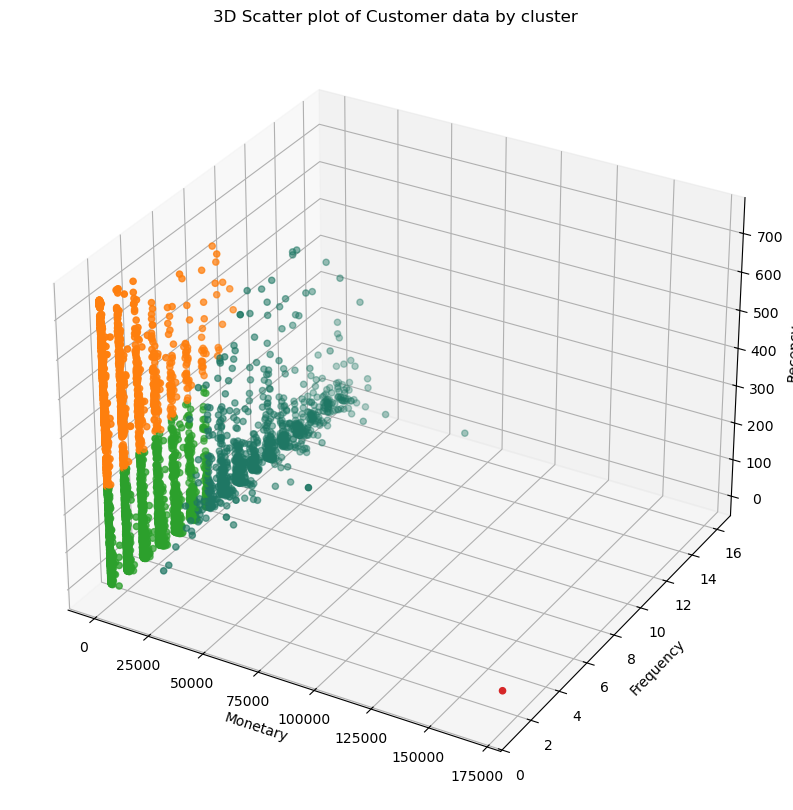

In [46]:
# plot clusters in 3D Scatter Plot
cluster_colors = {0:'#1f7764',  #Blue
                  1:'#ff7f0e',  #Orange
                  2:'#2ca02c',  #Green
                  3:'#d62728'}  #Red
colors = non_outliers["Cluster"].map(cluster_colors)
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(projection='3d')
scatter = ax.scatter(non_outliers['Monetary'],
                     non_outliers['Frequency'],
                     non_outliers['Recency'],
                     c=colors,
                     marker='o')
ax.set_xlabel("Monetary")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")
ax.set_title("3D Scatter plot of Customer data by cluster")
plt.show()

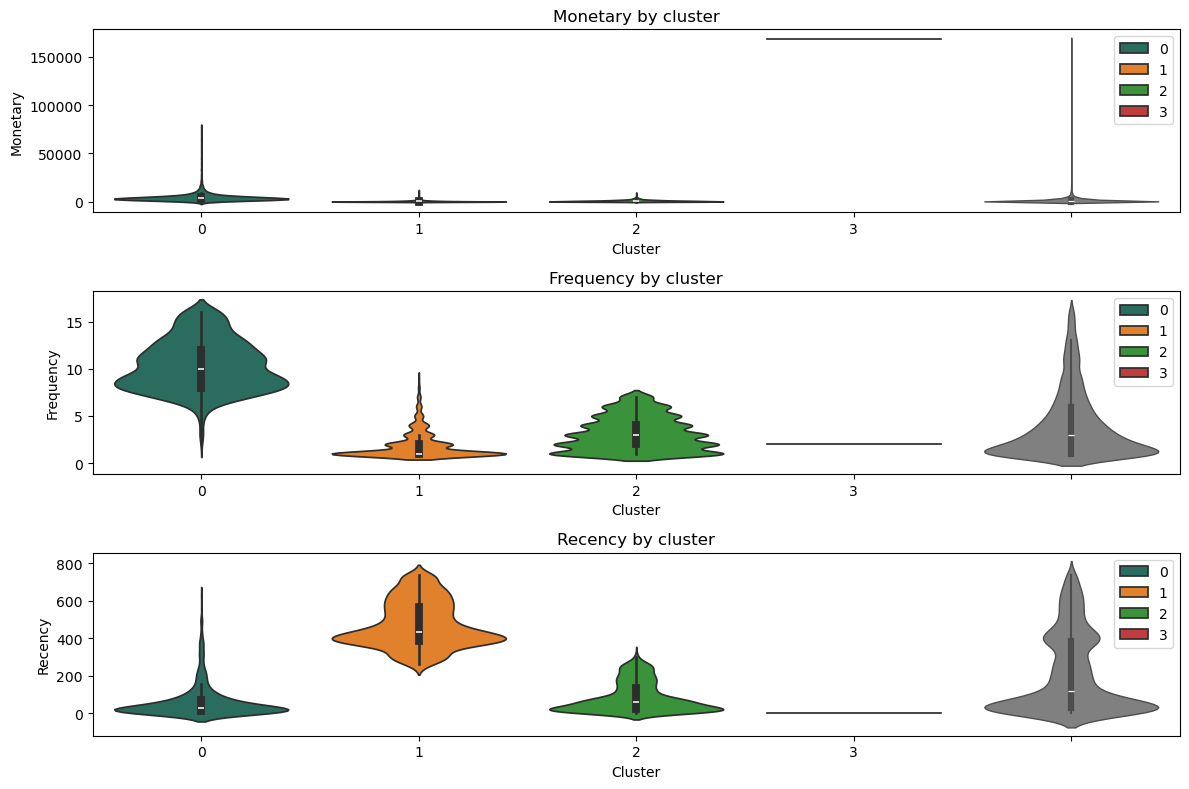

In [47]:
# violinplot by sns for name the clusters
plt.figure(figsize=(12,8))
# Monetary
plt.subplot(3,1,1)
sns.violinplot(x=non_outliers['Cluster'],y=non_outliers['Monetary'],palette=cluster_colors,hue=non_outliers['Cluster'])
sns.violinplot(y=non_outliers['Monetary'],color='gray',linewidth=1.0)
plt.title("Monetary by cluster")
plt.ylabel("Monetary")
# Frequency
plt.subplot(3,1,2)
sns.violinplot(x=non_outliers['Cluster'],y=non_outliers['Frequency'],palette=cluster_colors,hue=non_outliers['Cluster'])
sns.violinplot(y=non_outliers['Frequency'],color='gray',linewidth=1.0)
plt.title("Frequency by cluster")
plt.ylabel("Frequency")
# Recency
plt.subplot(3,1,3)
sns.violinplot(x=non_outliers['Cluster'],y=non_outliers['Recency'],palette=cluster_colors,hue=non_outliers['Cluster'])
sns.violinplot(y=non_outliers['Recency'],color='gray',linewidth=1.0)
plt.title("Recency by cluster")
plt.ylabel("Recency")
plt.tight_layout()
plt.show()



In [48]:
# Include outliers (monetary,frequency,overlap) into analysis
overlap_indices = monetary_outliers.index.intersection(frequency_outliers) #overlap both outliers
overlap_indices
monetary_only_outliers = monetary_outliers.drop(overlap_indices)
frequency_only_outliers = frequency_outliers.drop(overlap_indices)
monetary_and_frequency_outliers = pd.concat([monetary_only_outliers,frequency_only_outliers])
monetary_only_outliers["Cluster"]=-1
frequency_only_outliers["Cluster"]=-2
monetary_and_frequency_outliers["Cluster"]=-3  # assigning mannual cluster values
#Adding all 3 in outlier_cluster_df
outliers_cluster_df = pd.concat([monetary_only_outliers,frequency_only_outliers,monetary_and_frequency_outliers])
outliers_cluster_df

,Customer ID,Monetary,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.00,77352.96,3,2011-01-18 10:01:00,325,-1
1,12347.00,5633.32,8,2011-12-07 15:52:00,1,-1
10,12356.00,5613.68,6,2011-11-17 08:40:00,22,-1
11,12357.00,17437.66,2,2011-11-06 16:07:00,32,-1
13,12359.00,8935.94,10,2011-10-13 12:47:00,57,-1
...,...,...,...,...,...,...
5795,18231.00,6875.07,28,2011-05-31 14:18:00,191,-3
5805,18241.00,2986.99,21,2011-11-30 12:10:00,9,-3
5809,18245.00,6324.98,20,2011-12-02 14:48:00,6,-3
5824,18260.00,9962.11,23,2011-06-20 12:37:00,172,-3


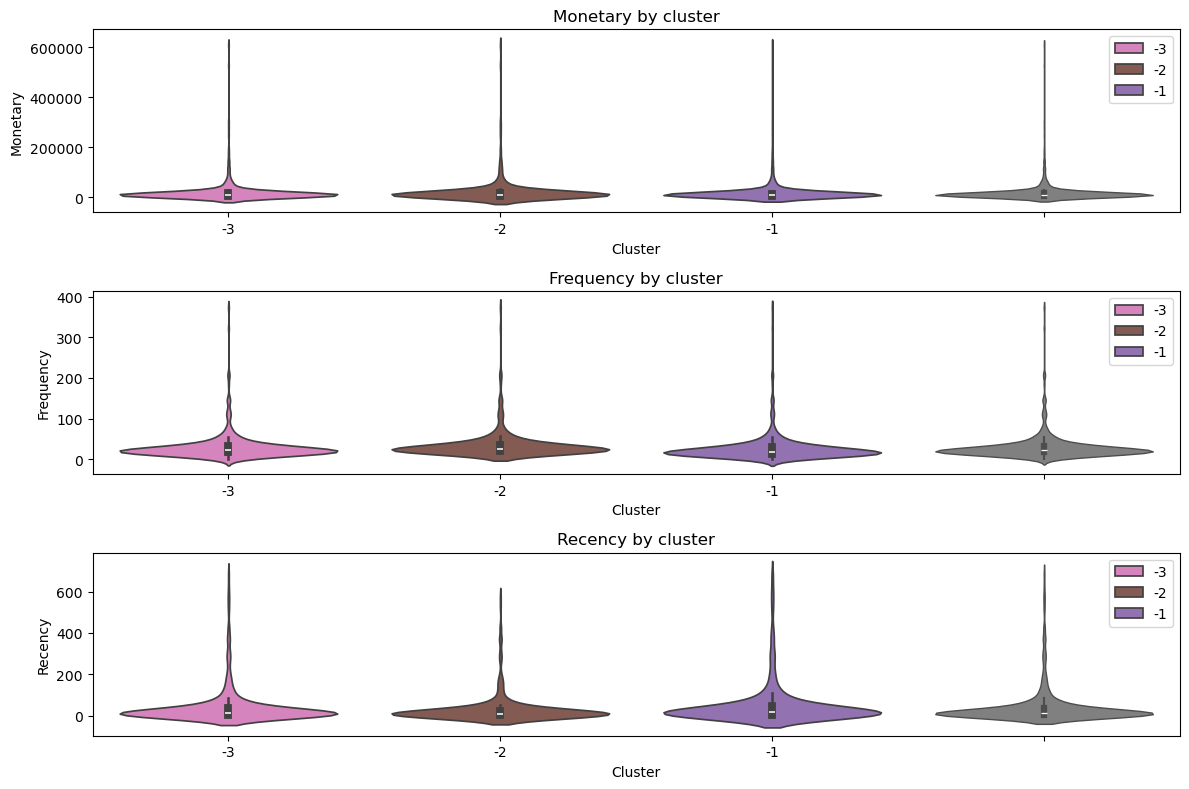

In [49]:
# violinplot for outlier_cluster_df
cluster_colors={-1:'#9467bd',
                -2:'#8c564b',
                -3:'#e377c2'}
 #violinplot by sns for outliers clusters
plt.figure(figsize=(12,8))
# Monetary
plt.subplot(3,1,1)
sns.violinplot(x=outliers_cluster_df['Cluster'],y=outliers_cluster_df['Monetary'],palette=cluster_colors,hue=outliers_cluster_df['Cluster'])
sns.violinplot(y=outliers_cluster_df['Monetary'],color='gray',linewidth=1.0)
plt.title("Monetary by cluster")
plt.ylabel("Monetary")
# Frequency
plt.subplot(3,1,2)
sns.violinplot(x=outliers_cluster_df['Cluster'],y=outliers_cluster_df['Frequency'],palette=cluster_colors,hue=outliers_cluster_df['Cluster'])
sns.violinplot(y=outliers_cluster_df['Frequency'],color='gray',linewidth=1.0)
plt.title("Frequency by cluster")
plt.ylabel("Frequency")
# Recency
plt.subplot(3,1,3)
sns.violinplot(x=outliers_cluster_df['Cluster'],y=outliers_cluster_df['Recency'],palette=cluster_colors,hue=outliers_cluster_df['Cluster'])
sns.violinplot(y=outliers_cluster_df['Recency'],color='gray',linewidth=1.0)
plt.title("Recency by cluster")
plt.ylabel("Recency")
plt.tight_layout()
plt.show()




In [50]:
# Naming clusters by cluster labels
cluster_labels={
    0:"Mid-Tire",
    1:"At Risk",
    2:"New",
    3:"Champion",
    -1:"Pamper",
    -2:"Upsell",
    -3:"Delight"
}

In [51]:
# Union non_outliers and outliers
full_clustering_df = pd.concat([non_outliers,outliers_cluster_df])
full_clustering_df

,Customer ID,Monetary,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.00,77352.96,3,2011-01-18 10:01:00,325,0
1,12347.00,5633.32,8,2011-12-07 15:52:00,1,0
2,12348.00,1658.40,5,2011-09-25 13:13:00,74,2
3,12349.00,3678.69,3,2011-11-21 09:51:00,18,2
4,12350.00,294.40,1,2011-02-02 16:01:00,309,1
...,...,...,...,...,...,...
5795,18231.00,6875.07,28,2011-05-31 14:18:00,191,-3
5805,18241.00,2986.99,21,2011-11-30 12:10:00,9,-3
5809,18245.00,6324.98,20,2011-12-02 14:48:00,6,-3
5824,18260.00,9962.11,23,2011-06-20 12:37:00,172,-3


In [52]:
# map cluster label to full_clustring_df
full_clustering_df["Cluster_Label"]=full_clustering_df["Cluster"].map(cluster_labels)
full_clustering_df


,Customer ID,Monetary,Frequency,LastInvoiceDate,Recency,Cluster,Cluster_Label
0,12346.00,77352.96,3,2011-01-18 10:01:00,325,0,Mid-Tire
1,12347.00,5633.32,8,2011-12-07 15:52:00,1,0,Mid-Tire
2,12348.00,1658.40,5,2011-09-25 13:13:00,74,2,New
3,12349.00,3678.69,3,2011-11-21 09:51:00,18,2,New
4,12350.00,294.40,1,2011-02-02 16:01:00,309,1,At Risk
...,...,...,...,...,...,...,...
5795,18231.00,6875.07,28,2011-05-31 14:18:00,191,-3,Delight
5805,18241.00,2986.99,21,2011-11-30 12:10:00,9,-3,Delight
5809,18245.00,6324.98,20,2011-12-02 14:48:00,6,-3,Delight
5824,18260.00,9962.11,23,2011-06-20 12:37:00,172,-3,Delight


Visualisation

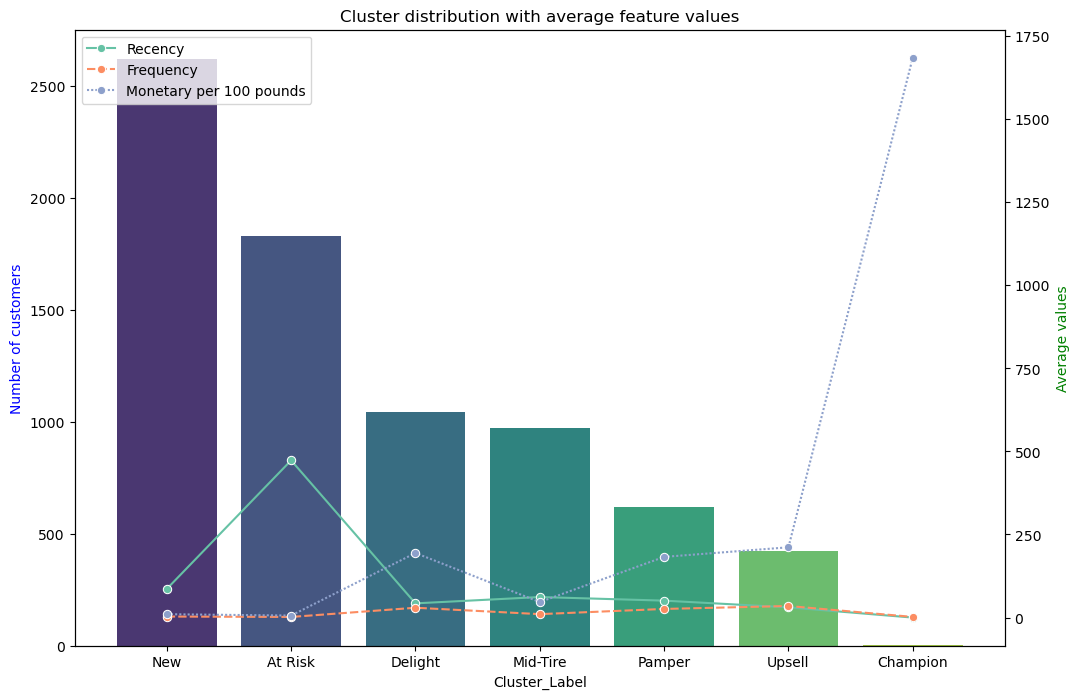

In [53]:
cluster_count = full_clustering_df["Cluster_Label"].value_counts()
full_clustering_df["Monetary per 100 pounds"]=full_clustering_df["Monetary"]/100.00  #High Monetary value so divide by 100.00
feature_means = full_clustering_df.groupby('Cluster_Label')[['Recency','Frequency','Monetary per 100 pounds']].mean()
fig,ax1=plt.subplots(figsize=(12,8))
sns.barplot(x=cluster_count.index,y=cluster_count.values, ax=ax1,palette='viridis',hue=cluster_count.index)
ax1.set_ylabel('Number of customers',color='b')
ax1.set_title('Cluster distribution with average feature values')
ax2=ax1.twinx()
sns.lineplot(data=feature_means,ax=ax2,palette='Set2',marker='o')
ax2.set_ylabel('Average values',color='g')
plt.show()

In [54]:
full_clustering_df.to_csv("clustered_data.csv",index=False)